Con riferimento al data set dell’esercitazione su clustering, eseguire una classificazione 
binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una 
regressione sulla feature aps. 
Di seguito si riportano i passi da seguire separatamente per ciascun task: 
1. Procedere allo split train-test secondo il rapporto 95%-15% in forma stratificata 
secondo i valori della variabile target. 
2. Eseguire l’imputazione dei dati mancanti con le stesse strategie dell’esercitazione 
precedente. 
3. Rimuovere le feature che presentano elevata correlazione con la variabile target e 
successivamente analizzare le possibili feature multicollineari rimanenti. 
4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a. Classificatore 
i. criterion: “gini”, “log_loss” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
b. Regressore 
i. criterion: “squared_error”, “absolute_error” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
5. Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva 
ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni 
classe, ciascuna valutata in modalità one-vs-rest. 
(*) Si noti che gli iperparametri indicati potrebbero non essere quelli ottimali perché il 
modello di addestri bene. Opzionalmente si discuta se non sia il caso di condizionare il 
modello ad altri iperparametri e si conducano le relative prove.

In [8]:
#import dataset
import pandas as pd

df =  pd.read_csv('./dataset_esercitazione.csv')
print(df.shape)

(9105, 43)


In [15]:
#split-dataset

from sklearn.model_selection import train_test_split

X = df.drop('dzgroup', axis=1)
y = df['dzgroup']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train)

           age     sex             dzclass  num.co   edu      income  scoma  \
5974  82.63696    male            ARF/MOSF       0  14.0         NaN    0.0   
8275  71.81897  female              Cancer       3  16.0  under $11k    0.0   
992   62.28897    male              Cancer       1  12.0  under $11k    0.0   
7830  33.19397    male            ARF/MOSF       0   NaN  under $11k    0.0   
3875  68.01898    male              Cancer       1   7.0         NaN    0.0   
...        ...     ...                 ...     ...   ...         ...    ...   
5118  64.86798    male  COPD/CHF/Cirrhosis       3  12.0    $11-$25k    0.0   
7690  61.85397    male            ARF/MOSF       0  11.0  under $11k    0.0   
4519  77.65900    male            ARF/MOSF       1  12.0  under $11k    9.0   
6415  75.78094  female  COPD/CHF/Cirrhosis       3  12.0  under $11k    0.0   
6787  55.38098  female  COPD/CHF/Cirrhosis       3  10.0  under $11k    0.0   

         charges       totcst       totmcst  ...   

In [16]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

cat_features = [ column  for column in X_train.columns if column not in numeric_features]


import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# 1. IMPUTATION
imputer1 = SimpleImputer(strategy='median').set_output(transform="pandas")
imputer2 = SimpleImputer(strategy='constant', fill_value='Unknown').set_output(transform="pandas")

# Fit e transform separati per tipo
X_tr_num = imputer1.fit_transform(X_train[numeric_features])
X_tr_cat = imputer2.fit_transform(X_train[cat_features])

X_te_num = imputer1.transform(X_test[numeric_features])
X_te_cat = imputer2.transform(X_test[cat_features])

# 2. ENCODING (Solo sulle colonne categoriche!)
encoder = OrdinalEncoder().set_output(transform="pandas")

# Applichiamo l'encoder SOLO ai pezzi categorici già imputati
X_tr_cat_enc = encoder.fit_transform(X_tr_cat)
X_te_cat_enc = encoder.transform(X_te_cat)

# 3. UNIONE FINALE (Numeri originali + Categorie encodate)
X_train_final = pd.concat([X_tr_num, X_tr_cat_enc], axis=1)
X_test_final = pd.concat([X_te_num, X_te_cat_enc], axis=1)

print(X_train_final.head())

           age  num.co   edu  scoma    charges      totcst      totmcst  \
5974  82.63696     0.0  14.0    0.0  36403.000  28387.4844   9901.22656   
8275  71.81897     3.0  16.0    0.0   4949.000   3180.9316   3546.20898   
992   62.28897     1.0  12.0    0.0  34721.000  16882.9219  19613.23440   
7830  33.19397     0.0  12.0    0.0  11717.000   9524.1484      0.00000   
3875  68.01898     1.0   7.0    0.0   3755.648   2598.2031  13237.47655   

      avtisst        sps   aps  ...  adlp  adls     adlsc  death  sex  \
5974     16.5  25.000000  46.0  ...   0.0   1.0  1.000000    0.0  1.0   
8275      7.0  11.798828  24.0  ...   0.0   1.0  2.199219    1.0  0.0   
992      14.5  13.298828  13.0  ...   0.0   0.0  0.000000    1.0  1.0   
7830     20.5  29.699219  31.0  ...   0.0   7.0  7.000000    1.0  1.0   
3875     17.0  16.597656  21.0  ...   0.0   0.0  0.000000    1.0  1.0   

      dzclass  income  race   ca  dnr  
5974      0.0     3.0   5.0  1.0  3.0  
8275      2.0     4.0   5.0  0

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
X_test_final[numeric_features] = scaler.transform(X_test_final[numeric_features])
print(X_train_final.head())


           age    num.co       edu     scoma   charges    totcst   totmcst  \
5974  1.283756 -1.393821  0.714622 -0.489616 -0.225719 -0.021040 -0.374728   
8275  0.589554  0.835721  1.352253 -0.489616 -0.530025 -0.594961 -0.557937   
992  -0.021996 -0.650640  0.076990 -0.489616 -0.241992 -0.282984 -0.094740   
7830 -1.889054 -1.393821  0.076990 -0.489616 -0.464547 -0.450534 -0.660171   
3875  0.345705 -0.650640 -1.517089 -0.489616 -0.541570 -0.608229 -0.278547   

       avtisst       sps       aps  ...      adlp      adls     adlsc  \
5974 -0.462969 -0.058712  0.413483  ... -0.365406 -0.236963 -0.447978   
8275 -1.185738 -1.383907 -0.681558  ... -0.365406 -0.236963  0.149928   
992  -0.615131 -1.233330 -1.229079  ... -0.365406 -0.770186 -0.946557   
7830 -0.158645  0.413018 -0.333136  ... -0.365406  2.962370  2.543499   
3875 -0.424929 -0.902178 -0.830882  ... -0.365406 -0.770186 -0.946557   

         death  sex  dzclass  income  race   ca  dnr  
5974 -1.459985  1.0      0.0     3.0 

In [18]:
#rimozione feature con alta correlazione

# 1. Calcoliamo la matrice (valore assoluto)
corr_matrix = X_train_final.corr().abs()

# 2. Creiamo un set per raccogliere le colonne da eliminare
# (usiamo un set così non aggiungiamo doppioni)
to_drop = set()

# 3. Ciclo for per confrontare ogni coppia di colonne
# i = indice della prima colonna
# j = indice della seconda colonna
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        # Se la correlazione tra la colonna i e la colonna j è > 0.7
        if corr_matrix.iloc[i, j] > 0.7:
            colname = corr_matrix.columns[i] # prendiamo il nome della colonna i
            to_drop.add(colname)

# 4. Trasformiamo il set in lista per poterlo usare nel drop
to_drop = list(to_drop)

print(f"Feature rimosse: {to_drop}")

# 5. Rimuoviamo le colonne
X_train_reduced = X_train_final.drop(columns=to_drop)
X_test_reduced = X_test_final.drop(columns=to_drop)

Feature rimosse: ['surv6m', 'adlsc', 'prg6m', 'aps', 'surv2m', 'totcst']


4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a. Classificatore 
i. criterion: “gini”, “log_loss” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
b. Regressore 
i. criterion: “squared_error”, “absolute_error” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
matrix_results = []
models_dict = {} 

for criterio in ['gini','log_loss']:
    for min_samples in [2,5,10]:
        for max_features in ['sqrt',5]:
            # Nome univoco per identificare il modello
            nome_modello = f"{criterio}_{min_samples}_{max_features}"
            
            clf = RandomForestClassifier(criterion=criterio, min_samples_split=min_samples, max_features=max_features, random_state=42)
            model = clf.fit(X_train_reduced, y_train)
            
            y_pred = model.predict(X_test_reduced)
            y_score = model.predict_proba(X_test_reduced)
            
            acc = accuracy_score(y_test, y_pred)
            auc_ovr_macro = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')
            
            result_entry = {
                'modello': nome_modello,
                'criterio': criterio,
                'min_samples': min_samples,
                'max_features': max_features,
                'accuracy': acc,
                'auc_macro': auc_ovr_macro
            }
            
            matrix_results.append(result_entry)
            models_dict[nome_modello] = model # Salviamo il modello fisico

df_risultati = pd.DataFrame(matrix_results)





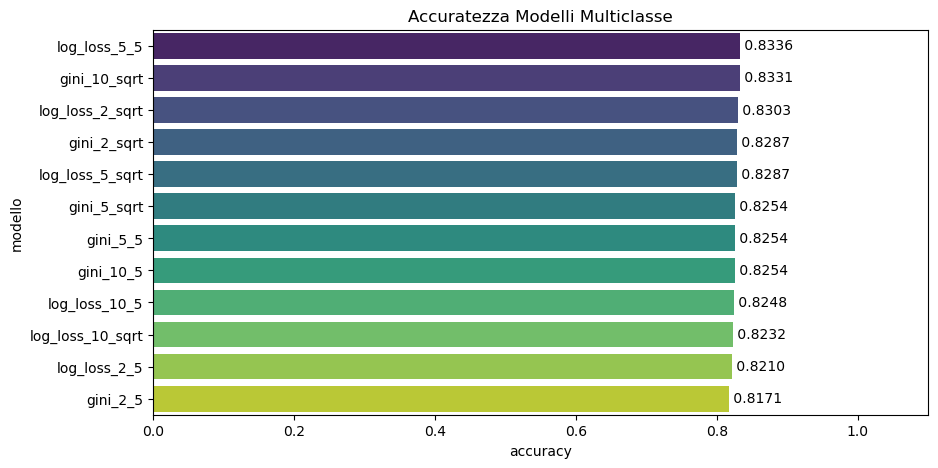

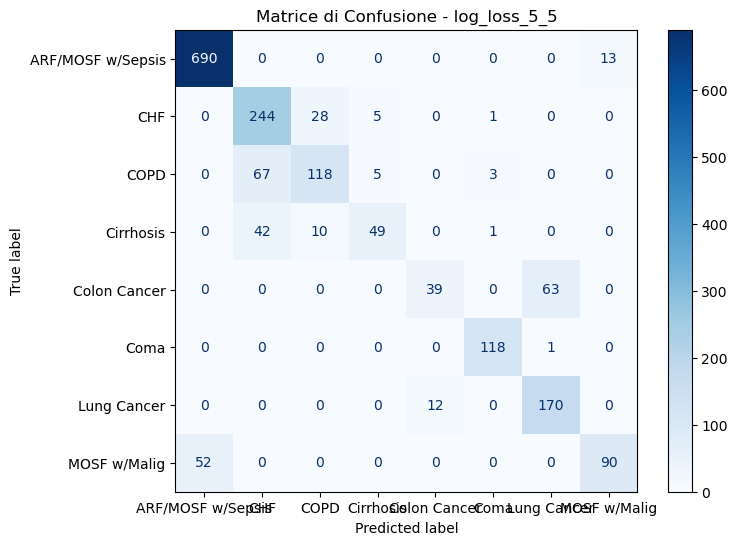

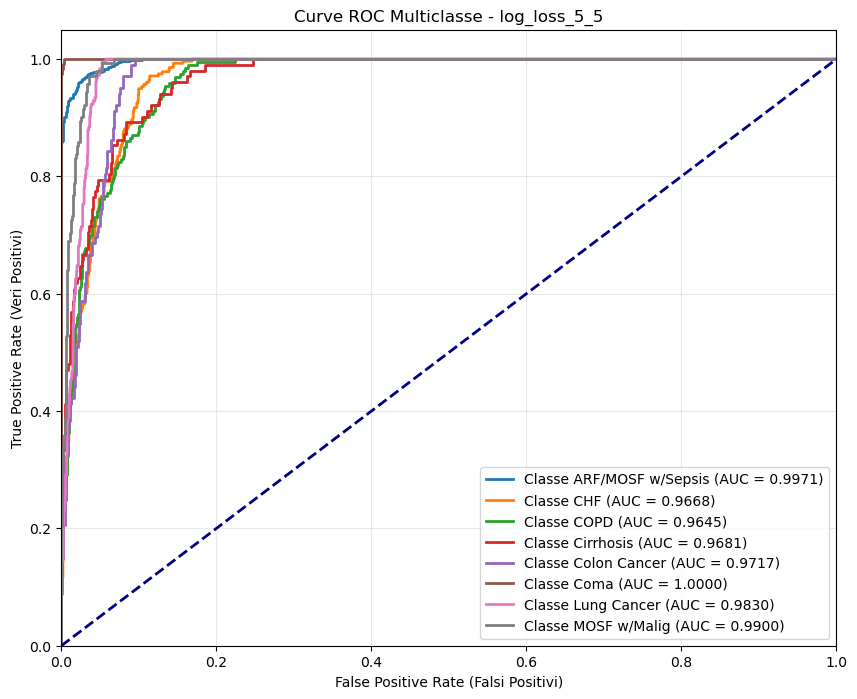

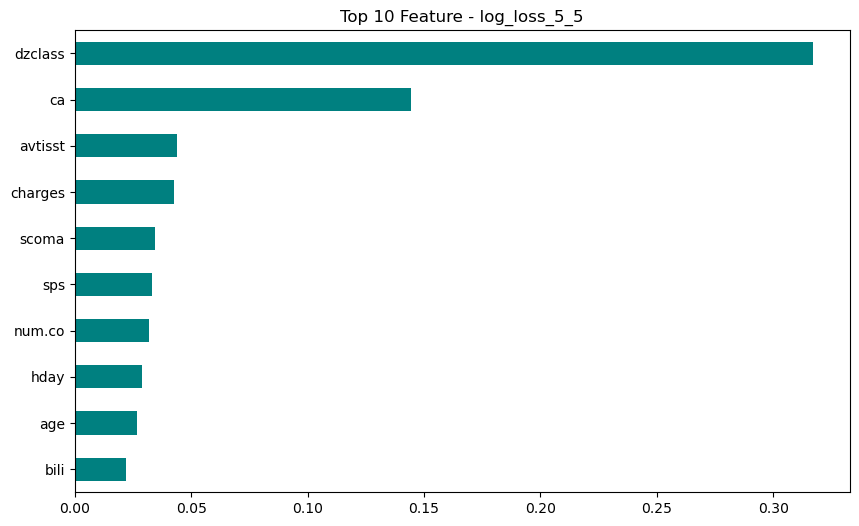

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

def visualizza_risultati_multiclasse_completi(df_risultati, X_test, y_test, modelli_salvati):
    """
    Visualizzazione specifica per multiclasse:
    1. Confronto Accuratezza modelli
    2. Matrice di Confusione
    3. Curve ROC e AUC specifiche PER OGNI CLASSE
    4. Feature Importance
    """
    
    # --- 1. PLOT ACCURACY ---
    plt.figure(figsize=(10, 5))
    df_plot = df_risultati.sort_values('accuracy', ascending=False)
    sns.barplot(x='accuracy', y='modello', data=df_plot, hue='modello', palette='viridis', legend=False)
    plt.title('Accuratezza Modelli Multiclasse')
    plt.xlim(0, 1.1)
    for i, val in enumerate(df_plot['accuracy']):
        plt.text(val, i, f' {val:.4f}', va='center')
    plt.show()

    # --- IDENTIFICAZIONE MIGLIOR MODELLO ---
    best_model_name = df_plot.iloc[0]['modello']
    best_clf = modelli_salvati[best_model_name]
    
    y_pred = best_clf.predict(X_test)
    y_score = best_clf.predict_proba(X_test)
    classes = best_clf.classes_
    n_classes = len(classes)

    # --- 2. MATRICE DI CONFUSIONE ---
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=classes, cmap='Blues', ax=ax)
    plt.title(f"Matrice di Confusione - {best_model_name}")
    plt.show()

    # --- 3. CURVE ROC E AUC PER OGNI CLASSE (One-vs-Rest) ---
    # Binarizziamo y_test per poter calcolare le curve classe per classe
    y_test_bin = label_binarize(y_test, classes=classes)
    
    plt.figure(figsize=(10, 8))
    
    for i in range(n_classes):
        # Calcolo curva ROC per la classe i-esima
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        
        # Plot della curva per ogni classe
        plt.plot(fpr, tpr, lw=2, label=f'Classe {classes[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Falsi Positivi)')
    plt.ylabel('True Positive Rate (Veri Positivi)')
    plt.title(f'Curve ROC Multiclasse - {best_model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    # --- 4. FEATURE IMPORTANCE ---
    plt.figure(figsize=(10, 6))
    importances = best_clf.feature_importances_
    feat_imp = pd.Series(importances, index=X_test.columns).sort_values(ascending=True).tail(10)
    feat_imp.plot(kind='barh', color='teal')
    plt.title(f"Top 10 Feature - {best_model_name}")
    plt.show()

# --- CHIAMATA ---
# Assicurati di usare il dizionario modelli_dict e il dataframe df_risultati creati per dzgroup
visualizza_risultati_multiclasse_completi(df_risultati, X_test_reduced, y_test, models_dict)